# ECG 12-Lead Reconstruction - Google Colab Training

**Paper**: [AI-enhanced reconstruction of the 12-lead ECG via 3-leads](https://www.nature.com/articles/s41746-024-01193-7)

This notebook uses the **exact original codebase** with **PTB-XL dataset**.

## Steps:
1. Check GPU
2. Mount Google Drive & load PTB-XL dataset
3. Get project code
4. Load/Convert PTB-XL data
5. Train model
6. Test & Visualize

## 0. Check GPU

In [1]:
# Check GPU availability
!nvidia-smi

import torch
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    DEVICE = 'cuda:0'
else:
    print("WARNING: No GPU! Go to Runtime -> Change runtime type -> GPU")
    DEVICE = 'cpu'

Tue Feb  3 12:06:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Mount Google Drive & Load PTB-XL Dataset

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [3]:
# Extract PTB-XL dataset from Google Drive
import os
from pathlib import Path

# Your dataset ZIP path on Google Drive
DRIVE_ZIP = '/content/drive/MyDrive/IMLE-Net-Project/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1.zip'

# Extract to /content/data
!mkdir -p /content/data
!unzip -q -o "{DRIVE_ZIP}" -d /content/data/

# Set PTBXL_PATH
extracted = list(Path('/content/data').glob('ptb-xl-*'))
PTBXL_PATH = str(extracted[0]) if extracted else None
print(f"PTBXL_PATH = {PTBXL_PATH}")
!ls {PTBXL_PATH}

error:  zipfile read error
PTBXL_PATH = /content/data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1
example_physionet.py  ptbxl_database.csv  records100
LICENSE.txt	      RECORDS		  SHA256SUMS.txt


## 2. Get Project Code & Install Dependencies

In [4]:
# Clone from GitHub and install dependencies
import os
PROJECT_DIR = '/content/ecg_reconstruction'

if not os.path.exists(PROJECT_DIR):
    print("Cloning from GitHub...")
    !git clone https://github.com/scripps-research/ecg_reconstruction.git {PROJECT_DIR}
else:
    print(f"Project already exists at {PROJECT_DIR}")

# Install wfdb with compatible pandas version
!pip install -q "pandas<3.0" wfdb tqdm

# Fix NumPy 2.0 compatibility (np.infty -> np.inf)
import numpy as np
if not hasattr(np, 'infty'):
    np.infty = np.inf
    print("Applied NumPy 2.0 compatibility fix (np.infty = np.inf)")

%cd {PROJECT_DIR}
!ls -la

Cloning from GitHub...
Cloning into '/content/ecg_reconstruction'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 70 (delta 16), reused 63 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 94.34 KiB | 1.50 MiB/s, done.
Resolving deltas: 100% (16/16), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 102.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Applied NumPy 2.0 compatibility fix (np.infty = np.inf)
/content/ecg_reconstruction
total 148
drwxr-xr-x 10 root r

In [5]:
# Create general_ptbxl.py (adapts original code to use pickle instead of MongoDB)
# This version properly handles MongoDB $in operator for batch queries

general_ptbxl_code = '''
import json
import shutil
import pickle
import os
import pandas as pd
import numpy as np

class PickleCollection:
    """Mimics MongoDB collection interface using pickle files"""
    def __init__(self, data_list):
        # Store as list and create index for fast lookup
        self.data = data_list
        self.index = {item['ElementID']: item for item in data_list}

    def find_one(self, query):
        """Find a single document matching the query"""
        if query is None:
            return self.data[0] if self.data else None

        # Handle ElementID lookup
        if 'ElementID' in query:
            element_id = query['ElementID']
            item = self.index.get(element_id)
            if item:
                return self._convert_item(item)
            return None

        # Handle _id lookup (treat as ElementID)
        if '_id' in query:
            element_id = query['_id']
            item = self.index.get(element_id)
            if item:
                return self._convert_item(item)
            return None

        return None

    def find(self, query=None):
        """Find documents matching the query - supports MongoDB $in operator"""
        if query is None:
            return [self._convert_item(item) for item in self.data]

        results = []

        # Handle ElementID with $in operator (batch query)
        if 'ElementID' in query:
            value = query['ElementID']
            if isinstance(value, dict) and '$in' in value:
                # Batch lookup using $in operator
                element_ids = value['$in']
                for eid in element_ids:
                    item = self.index.get(eid)
                    if item:
                        results.append(self._convert_item(item))
                return results
            else:
                # Single lookup
                item = self.index.get(value)
                if item:
                    return [self._convert_item(item)]
                return []

        # Handle _id with $in operator
        if '_id' in query:
            value = query['_id']
            if isinstance(value, dict) and '$in' in value:
                element_ids = value['$in']
                for eid in element_ids:
                    item = self.index.get(eid)
                    if item:
                        results.append(self._convert_item(item))
                return results
            else:
                item = self.index.get(value)
                if item:
                    return [self._convert_item(item)]
                return []

        # Handle $or operator
        if '$or' in query:
            for sub_query in query['$or']:
                results.extend(self.find(sub_query))
            return results

        # Generic field matching
        for item in self.data:
            match = True
            for key, value in query.items():
                if item.get(key) != value:
                    match = False
                    break
            if match:
                results.append(self._convert_item(item))

        return results

    def _convert_item(self, item):
        """Convert numpy arrays to pd.Series for compatibility"""
        item_copy = dict(item)
        if 'lead' in item_copy:
            item_copy['lead'] = {
                k: pd.Series(v) if isinstance(v, np.ndarray) else v
                for k, v in item_copy['lead'].items()
            }
        return item_copy

    def count_documents(self, query=None):
        return len(self.find(query))

_data_collection = None

def get_collection(database_params_file=None):
    """Load data from pickle instead of MongoDB"""
    global _data_collection
    if _data_collection is None:
        pickle_path = os.path.join(get_parent_folder(), 'Feature_map', 'Dataset', 'data_collection.pkl')
        print(f"Loading data collection from {pickle_path}...")
        with open(pickle_path, 'rb') as f:
            _data_collection = pickle.load(f)
        print(f"Loaded {len(_data_collection)} records")
    return PickleCollection(_data_collection)

def get_parent_folder():
    return "/content/Data/"

def remove_dir(folder: str):
    try:
        shutil.rmtree(folder)
    except:
        pass

def get_twelve_keys():
    return ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

def get_lead_keys(leads: str):
    if leads == 'limb':
        keys = ['I', 'II']
    elif leads == 'limb+comb(v3+v4)':
        keys = ['I', 'II', ['V3', 'V4']]
    elif leads == 'limb+v2+v4':
        keys = ['I', 'II', 'V2', 'V4']
    elif leads == 'full_limb':
        keys = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF']
    elif leads == 'limb+v1':
        keys = ['I', 'II', 'V1']
    elif leads == 'limb+v2':
        keys = ['I', 'II', 'V2']
    elif leads == 'limb+v3':
        keys = ['I', 'II', 'V3']
    elif leads == 'limb+v4':
        keys = ['I', 'II', 'V4']
    elif leads == 'limb+v5':
        keys = ['I', 'II', 'V5']
    elif leads == 'limb+v6':
        keys = ['I', 'II', 'V6']
    elif leads == 'precordial':
        keys = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    elif leads == 'full':
        keys = ['I', 'II', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    else:
        raise ValueError(f"Unknown leads: {leads}")
    return keys

def get_data_classes(dataset: str):
    # For PTB-XL, use 'other' to load ALL data without class filtering
    if dataset == 'other' or dataset == 'all':
        data_classes = ['other']
    elif dataset == 'infarct+other':
        data_classes = ['st_elevation_or_infarct', 'other']
    elif dataset == 'infarct+noninfarct':
        data_classes = ['st_elevation_or_infarct', 'non_st_elevation_or_infarct']
    else:
        data_classes = ['other']  # Default to 'other' for PTB-XL
    return data_classes

def get_detect_classes(detect_class: str):
    detect_classes = [detect_class]
    return detect_classes

def get_value_range():
    min_value = -2.5
    amplitude = 5.0
    wave_sample = 2500
    return min_value, amplitude, wave_sample
'''

with open('util_functions/general_ptbxl.py', 'w') as f:
    f.write(general_ptbxl_code)
print("Created util_functions/general_ptbxl.py")

Created util_functions/general_ptbxl.py


## 3. Load or Convert PTB-XL Data

If data is already converted and saved to Google Drive, it will be loaded directly. Otherwise, conversion will run.

In [6]:
# Check if converted data exists on Drive
import os
import shutil

DATA_DIR = '/content/Data'
DRIVE_DATA_PATH = '/content/drive/MyDrive/ECG_Reconstruction/Data'

# Remove any broken symlinks
if os.path.islink(DATA_DIR):
    os.remove(DATA_DIR)

# Check if already converted and saved to Drive
if os.path.exists(f'{DRIVE_DATA_PATH}/Feature_map/Dataset/data_collection.pkl'):
    print("Found converted data on Drive! Copying...")
    !rm -rf {DATA_DIR}
    !cp -r '{DRIVE_DATA_PATH}' {DATA_DIR}
    print("Loaded from Drive (skipping conversion)")
    SKIP_CONVERSION = True
else:
    print("No converted data on Drive. Will convert from scratch.")
    !rm -rf {DATA_DIR}
    !mkdir -p {DATA_DIR}
    SKIP_CONVERSION = False

print(f"\nData directory: {DATA_DIR}")

Found converted data on Drive! Copying...
Loaded from Drive (skipping conversion)

Data directory: /content/Data


In [7]:
# Convert PTB-XL data (only runs if not loaded from Drive)
if not SKIP_CONVERSION:
    import pickle
    import numpy as np
    import pandas as pd
    import wfdb
    from tqdm import tqdm
    from sklearn.model_selection import train_test_split
    import gc

    # Load database
    df = pd.read_csv(f'{PTBXL_PATH}/ptbxl_database.csv', index_col='ecg_id')
    df.scp_codes = df.scp_codes.apply(eval)
    print(f"Found {len(df)} records")

    lead_map = {'AVR': 'aVR', 'AVL': 'aVL', 'AVF': 'aVF'}
    os.makedirs(f'{DATA_DIR}/Feature_map/Dataset', exist_ok=True)

    # Process in chunks to avoid memory issues
    CHUNK_SIZE = 2000
    chunks = []

    for chunk_idx, start in enumerate(range(0, len(df), CHUNK_SIZE)):
        chunk_df = df.iloc[start:start+CHUNK_SIZE]
        chunk_data = []

        for ecg_id, row in tqdm(chunk_df.iterrows(), total=len(chunk_df), desc=f"Chunk {chunk_idx+1}"):
            try:
                record_path = f"{PTBXL_PATH}/{row['filename_hr']}"
                record = wfdb.rdrecord(record_path)
                signal = record.p_signal

                lead_dict = {}
                for i, name in enumerate(record.sig_name):
                    mapped = lead_map.get(name, name)
                    lead_dict[mapped] = (signal[:, i] * 1000).astype(np.float32)

                element = {
                    'ElementID': f'ptbxl_{ecg_id}',
                    'lead': lead_dict,
                    'patient_id': row['patient_id']
                }
                chunk_data.append(element)
            except:
                pass

        # Save chunk
        chunk_path = f'{DATA_DIR}/Feature_map/Dataset/chunk_{chunk_idx}.pkl'
        with open(chunk_path, 'wb') as f:
            pickle.dump(chunk_data, f, protocol=4)
        print(f"  Saved chunk {chunk_idx+1}: {len(chunk_data)} records")
        chunks.append(chunk_path)
        del chunk_data
        gc.collect()

    # Combine chunks
    print("Combining chunks...")
    all_data = []
    for chunk_path in chunks:
        with open(chunk_path, 'rb') as f:
            all_data.extend(pickle.load(f))
        os.remove(chunk_path)
        gc.collect()

    print(f"Total records: {len(all_data)}")

    # Save final file
    pkl_path = f'{DATA_DIR}/Feature_map/Dataset/data_collection.pkl'
    print("Saving final file...")
    with open(pkl_path, 'wb') as f:
        pickle.dump(all_data, f, protocol=4)

    size_mb = os.path.getsize(pkl_path) / 1024 / 1024
    print(f"Done! File size: {size_mb:.1f} MB")

    # Create train/valid/test splits
    element_ids = [d['ElementID'] for d in all_data]
    patient_map_dict = {d['ElementID']: d['patient_id'] for d in all_data}
    patients = list(set(patient_map_dict.values()))

    train_p, temp_p = train_test_split(patients, test_size=0.3, random_state=42)
    valid_p, test_p = train_test_split(temp_p, test_size=0.5, random_state=42)

    train_p_set, valid_p_set, test_p_set = set(train_p), set(valid_p), set(test_p)
    train_ids = [e for e in element_ids if patient_map_dict[e] in train_p_set]
    valid_ids = [e for e in element_ids if patient_map_dict[e] in valid_p_set]
    test_ids = [e for e in element_ids if patient_map_dict[e] in test_p_set]

    print(f"Split: Train={len(train_ids)}, Valid={len(valid_ids)}, Test={len(test_ids)}")

    # Save Dataset maps
    dataset_path = f'{DATA_DIR}/Feature_map/Dataset'
    all_patients = list(patient_map_dict.values())
    train_patients = [patient_map_dict[e] for e in train_ids]
    valid_patients = [patient_map_dict[e] for e in valid_ids]
    test_patients = [patient_map_dict[e] for e in test_ids]

    for name, data in [('map', element_ids), ('clean_map', element_ids), ('corrupted_map', []),
                       ('train_map', train_ids), ('valid_map', valid_ids), ('test_map', test_ids),
                       ('patient_map', all_patients), ('clean_patient_map', all_patients), ('corrupted_patient_map', []),
                       ('train_patient_map', train_patients), ('valid_patient_map', valid_patients), ('test_patient_map', test_patients)]:
        with open(f'{dataset_path}/{name}.pkl', 'wb') as f:
            pickle.dump(data, f)

    # Create 'other' Dataclass (contains ALL data - required by the codebase)
    other_path = f'{DATA_DIR}/Feature_map/Dataclass/other'
    os.makedirs(other_path, exist_ok=True)

    for name, data in [('map', element_ids), ('clean_map', element_ids), ('corrupted_map', []),
                       ('train_map', train_ids), ('valid_map', valid_ids), ('test_map', test_ids),
                       ('patient_map', all_patients), ('clean_patient_map', all_patients), ('corrupted_patient_map', []),
                       ('train_patient_map', train_patients), ('valid_patient_map', valid_patients), ('test_patient_map', test_patients)]:
        with open(f'{other_path}/{name}.pkl', 'wb') as f:
            pickle.dump(data, f)

    print(f"Created 'other' Dataclass with {len(element_ids)} records")

    del all_data
    gc.collect()
    print("Conversion complete!")
else:
    print("Skipped conversion - data already loaded from Drive")

Skipped conversion - data already loaded from Drive


In [8]:
# Create required map files if missing (needed when loading from Drive)
import pickle
import os
from sklearn.model_selection import train_test_split

DATA_DIR = '/content/Data'
dataset_path = f'{DATA_DIR}/Feature_map/Dataset'
other_path = f'{DATA_DIR}/Feature_map/Dataclass/other'

# Check if train_map.pkl exists in Dataset folder
if not os.path.exists(f'{dataset_path}/train_map.pkl'):
    print("Creating required map files...")

    # Load data collection
    with open(f'{dataset_path}/data_collection.pkl', 'rb') as f:
        data_list = pickle.load(f)
    print(f"Loaded {len(data_list)} records")

    # Extract IDs and patient info
    element_ids = [d['ElementID'] for d in data_list]
    patient_map_dict = {d['ElementID']: d['patient_id'] for d in data_list}
    patients = list(set(patient_map_dict.values()))

    # Create train/valid/test splits
    train_p, temp_p = train_test_split(patients, test_size=0.3, random_state=42)
    valid_p, test_p = train_test_split(temp_p, test_size=0.5, random_state=42)

    train_p_set, valid_p_set, test_p_set = set(train_p), set(valid_p), set(test_p)
    train_ids = [e for e in element_ids if patient_map_dict[e] in train_p_set]
    valid_ids = [e for e in element_ids if patient_map_dict[e] in valid_p_set]
    test_ids = [e for e in element_ids if patient_map_dict[e] in test_p_set]

    print(f"Split: Train={len(train_ids)}, Valid={len(valid_ids)}, Test={len(test_ids)}")

    # Patient lists
    all_patients = list(patient_map_dict.values())
    train_patients = [patient_map_dict[e] for e in train_ids]
    valid_patients = [patient_map_dict[e] for e in valid_ids]
    test_patients = [patient_map_dict[e] for e in test_ids]

    # All files to create
    all_maps = [
        ('map', element_ids), ('clean_map', element_ids), ('corrupted_map', []),
        ('train_map', train_ids), ('valid_map', valid_ids), ('test_map', test_ids),
        ('patient_map', all_patients), ('clean_patient_map', all_patients), ('corrupted_patient_map', []),
        ('train_patient_map', train_patients), ('valid_patient_map', valid_patients), ('test_patient_map', test_patients)
    ]

    # Save to Dataset folder
    for name, data in all_maps:
        with open(f'{dataset_path}/{name}.pkl', 'wb') as f:
            pickle.dump(data, f)
    print(f"Saved {len(all_maps)} files to Dataset/")

    # Create 'other' Dataclass folder
    os.makedirs(other_path, exist_ok=True)
    for name, data in all_maps:
        with open(f'{other_path}/{name}.pkl', 'wb') as f:
            pickle.dump(data, f)
    print(f"Created 'other' Dataclass")

    del data_list
    import gc
    gc.collect()
else:
    print("Map files already exist")
    # Still ensure 'other' Dataclass exists
    if not os.path.exists(f'{other_path}/train_map.pkl'):
        print("Creating 'other' Dataclass...")
        os.makedirs(other_path, exist_ok=True)
        for filename in os.listdir(dataset_path):
            if filename.endswith('.pkl') and filename != 'data_collection.pkl':
                with open(f'{dataset_path}/{filename}', 'rb') as f:
                    data = pickle.load(f)
                with open(f'{other_path}/{filename}', 'wb') as f:
                    pickle.dump(data, f)
        print("Created 'other' Dataclass")

Map files already exist


In [9]:
# Save converted data to Google Drive (run after first conversion)
import shutil
import os

DRIVE_DATA_PATH = '/content/drive/MyDrive/ECG_Reconstruction/Data'

# Check if Drive data needs updating
needs_update = os.path.exists(DATA_DIR) and (
    not os.path.exists(DRIVE_DATA_PATH) or
    not os.path.exists(f'{DRIVE_DATA_PATH}/Feature_map/Dataset/train_map.pkl') or
    not os.path.exists(f'{DRIVE_DATA_PATH}/Feature_map/Dataclass/other/train_map.pkl')
)

if needs_update:
    print(f"Saving/updating Google Drive: {DRIVE_DATA_PATH}")
    print("This may take a few minutes...")
    if os.path.exists(DRIVE_DATA_PATH):
        shutil.rmtree(DRIVE_DATA_PATH)
    shutil.copytree(DATA_DIR, DRIVE_DATA_PATH)
    print("Saved to Drive!")
else:
    print("Data on Drive is up to date")

Data on Drive is up to date


In [10]:
import os
import shutil
from tqdm import tqdm

src = '/content/Data/Feature_map/Dataset/data_collection.pkl'
dst = '/content/drive/MyDrive/ECG_Reconstruction/Data/Feature_map/Dataset/data_collection.pkl'

# Make sure destination folder exists
os.makedirs(os.path.dirname(dst), exist_ok=True)

# Get file size
file_size = os.path.getsize(src)
print(f"Copying: {file_size / (1024**3):.2f} GB")

# Copy with progress bar
chunk_size = 1024 * 1024  # 1 MB chunks

with open(src, 'rb') as fsrc:
    with open(dst, 'wb') as fdst:
        with tqdm(total=file_size, unit='B', unit_scale=True, desc='Uploading to Drive') as pbar:
            while True:
                chunk = fsrc.read(chunk_size)
                if not chunk:
                    break
                fdst.write(chunk)
                pbar.update(len(chunk))

print("Done!")

Copying: 4.89 GB


Uploading to Drive: 100%|██████████| 5.25G/5.25G [00:49<00:00, 107MB/s]


Done!


In [11]:
# Verify data setup
import os
import pickle

print("Dataset contents:")
!ls -la {DATA_DIR}/Feature_map/Dataset/ | head -15

print("\nDataclass 'other' contents:")
!ls -la {DATA_DIR}/Feature_map/Dataclass/other/

# Verify pickle file is valid
pkl_path = f'{DATA_DIR}/Feature_map/Dataset/data_collection.pkl'
try:
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    print(f"\ndata_collection.pkl is valid! Contains {len(data)} records")
    print(f"Sample ElementID: {data[0]['ElementID']}")
    del data
except Exception as e:
    print(f"\nERROR: {e}")
    print("You need to re-run the conversion cell")

Dataset contents:
total 5131056
drwx------ 2 root root       4096 Feb  3 12:09 .
drwx------ 4 root root       4096 Feb  3 12:09 ..
-rw------- 1 root root     196609 Feb  3 12:09 clean_patient_map.pkl
-rw------- 1 root root          5 Feb  3 12:09 corrupted_map.pkl
-rw------- 1 root root          5 Feb  3 12:09 corrupted_patient_map.pkl
-rw------- 1 root root 5253317883 Feb  3 12:09 data_collection.pkl
-rw------- 1 root root     196609 Feb  3 12:09 patient_map.pkl
-rw------- 1 root root      44369 Feb  3 12:09 test_map.pkl
-rw------- 1 root root      29623 Feb  3 12:09 test_patient_map.pkl
-rw------- 1 root root     206229 Feb  3 12:09 train_map.pkl
-rw------- 1 root root     137602 Feb  3 12:09 train_patient_map.pkl
-rw------- 1 root root      29416 Feb  3 12:09 valid_patient_map.pkl

Dataclass 'other' contents:
total 1476
drwx------ 2 root root   4096 Feb  3 12:10 .
drwx------ 3 root root   4096 Feb  3 12:09 ..
-rw------- 1 root root 294706 Feb  3 12:10 clean_map.pkl
-rw------- 1 root

In [12]:
# Copy missing files from Dataclass/other to Dataset
import shutil
import os

dataset_path = '/content/Data/Feature_map/Dataset'
other_path = '/content/Data/Feature_map/Dataclass/other'

missing_files = ['valid_map.pkl', 'map.pkl', 'clean_map.pkl']

for filename in missing_files:
    src = f'{other_path}/{filename}'
    dst = f'{dataset_path}/{filename}'
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f"Copied {filename}")
    elif os.path.exists(dst):
        print(f"{filename} already exists")
    else:
        print(f"WARNING: {filename} not found in source")

print("\nDataset folder now contains:")
for f in sorted(os.listdir(dataset_path)):
    if f.endswith('.pkl'):
        print(f"  {f}")

Copied valid_map.pkl
Copied map.pkl
Copied clean_map.pkl

Dataset folder now contains:
  clean_map.pkl
  clean_patient_map.pkl
  corrupted_map.pkl
  corrupted_patient_map.pkl
  data_collection.pkl
  map.pkl
  patient_map.pkl
  test_map.pkl
  test_patient_map.pkl
  train_map.pkl
  train_patient_map.pkl
  valid_map.pkl
  valid_patient_map.pkl


In [13]:
# Patch original code to use PTB-XL adapter
!cp util_functions/general.py util_functions/general_backup.py
!cp util_functions/general_ptbxl.py util_functions/general.py

print("Code patched to use PTB-XL data!")

Code patched to use PTB-XL data!


## 4. Configuration (Paper Settings)

In [14]:
# Configuration based on Paper (Nature s41746-024-01193-7)

CONFIG = {
    'device': DEVICE,

    # INPUT/OUTPUT LEADS (Paper: I + II + V3 -> V1-V6)
    'input_leads': 'limb+v3',     # I, II, V3 (3 leads)
    'output_leads': 'precordial', # V1-V6 (6 leads)

    # Dataset - use 'other' to load ALL PTB-XL data
    'dataset': 'other',
    'data_size': 'max',

    # Network architecture (Paper: ResCNN blocks)
    'input_channel': 32,
    'middle_channel': 32,
    'output_channel': 32,
    'input_depth': 3,
    'middle_depth': 2,
    'output_depth': 3,
    'input_kernel': 17,
    'middle_kernel': 17,
    'output_kernel': 17,
    'use_residual': 'true',

    # Training parameters
    'epochs': 200,
    'batch_size': 16,
    'optimizer_algorithm': 'adam',
    'learning_rate': 0.000003,
    'weight_decay': 0.001,
    'momentum': 0.9,
    'nesterov': True,
    'prioritize_percent': 0,
    'prioritize_size': 0,
}

print("="*60)
print("CONFIGURATION (Paper Settings)")
print("="*60)
print(f"Input:  {CONFIG['input_leads']} (I, II, V3)")
print(f"Output: {CONFIG['output_leads']} (V1-V6)")
print(f"Device: {CONFIG['device']}")
print(f"Dataset: {CONFIG['dataset']} (all PTB-XL data)")
print(f"Epochs: {CONFIG['epochs']}")
print("="*60)

CONFIGURATION (Paper Settings)
Input:  limb+v3 (I, II, V3)
Output: precordial (V1-V6)
Device: cuda:0
Dataset: other (all PTB-XL data)
Epochs: 200


## 5. Initialize Model

In [15]:
# # Clear local checkpoints to start fresh
# import shutil
# import os

# # Clear local output folder
# local_output = '/content/Data/Analysis/'
# if os.path.exists(local_output):
#     shutil.rmtree(local_output)
#     print(f"Cleared local checkpoints: {local_output}")

# # Also clear Drive checkpoints (if needed)
# drive_checkpoints = '/content/drive/MyDrive/ECG_Reconstruction/Checkpoints'
# if os.path.exists(drive_checkpoints):
#     shutil.rmtree(drive_checkpoints)
#     print(f"Cleared Drive checkpoints: {drive_checkpoints}")

# print("Ready to start fresh training!")


In [16]:
import sys
sys.path.insert(0, '.')

# Fix NumPy 2.0 compatibility before importing
import numpy as np
if not hasattr(np, 'infty'):
    np.infty = np.inf

from util_functions.general import get_parent_folder, get_data_classes, get_lead_keys
from training_functions.single_reconstruction_manager import ReconstructionManager

# Get settings
parent_folder = get_parent_folder()
data_classes = get_data_classes(CONFIG['dataset'])  # Returns ['other']
sub_classes = []

# Show lead configuration
input_keys = get_lead_keys(CONFIG['input_leads'])
output_keys = get_lead_keys(CONFIG['output_leads'])
print(f"Input leads ({len(input_keys)}): {input_keys}")
print(f"Output leads ({len(output_keys)}): {output_keys}")
print(f"Data classes: {data_classes}")
print(f"Data folder: {parent_folder}")

Input leads (3): ['I', 'II', 'V3']
Output leads (6): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Data classes: ['other']
Data folder: /content/Data/


In [17]:
# Create the Reconstruction Manager
manager = ReconstructionManager(
    parent_folder=parent_folder,
    device=CONFIG['device'],
    sub_classes=sub_classes,
    input_leads=CONFIG['input_leads'],
    output_leads=CONFIG['output_leads'],
    data_classes=data_classes,
    data_size=CONFIG['data_size'],
    input_channel=CONFIG['input_channel'],
    middle_channel=CONFIG['middle_channel'],
    output_channel=CONFIG['output_channel'],
    input_depth=CONFIG['input_depth'],
    middle_depth=CONFIG['middle_depth'],
    output_depth=CONFIG['output_depth'],
    input_kernel=CONFIG['input_kernel'],
    middle_kernel=CONFIG['middle_kernel'],
    output_kernel=CONFIG['output_kernel'],
    use_residual=CONFIG['use_residual'],
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    prioritize_percent=CONFIG['prioritize_percent'],
    prioritize_size=CONFIG['prioritize_size'],
    optimizer_algorithm=CONFIG['optimizer_algorithm'],
    learning_rate=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    momentum=CONFIG['momentum'],
    nesterov=CONFIG['nesterov']
)

print("Reconstruction Manager initialized!")

Loading data collection from /content/Data/Feature_map/Dataset/data_collection.pkl...
Loaded 21837 records
Reconstruction Manager initialized!


## 6. Training

In [18]:
# Initialize model
print("Initializing model...")
manager.reset_model()
print("Model initialized!")

Initializing model...
Model initialized!


In [19]:
# Load datasets
print("Loading training and validation datasets...")
manager.load_dataset(train=True, valid=True)
print("Datasets loaded!")

Loading training and validation datasets...
Loaded  1000  data!
Loaded  2000  data!
Loaded  3000  data!
Loaded  4000  data!
Loaded  5000  data!
Loaded  6000  data!
Loaded  7000  data!
Loaded  8000  data!
Loaded  9000  data!
Loaded  10000  data!
Loaded  11000  data!
Loaded  12000  data!
Loaded  13000  data!
Loaded  14000  data!
Loaded  15000  data!
Loaded 15282 data!
Loaded  1000  data!
Loaded  2000  data!
Loaded  3000  data!
Loaded 3266 data!
Datasets loaded!


In [20]:
# Add progress bars to training with metrics display (run this BEFORE training)
import sys
import time
import os
import shutil
import pickle

def train_with_progress(self):
    total_epochs = self.epochs
    drive_save_path = '/content/drive/MyDrive/ECG_Reconstruction/Checkpoints'

    os.makedirs(drive_save_path, exist_ok=True)

    # Try to resume from previous checkpoint
    resume_path = f"{drive_save_path}/latest"
    if os.path.exists(resume_path) and self.current_epoch == 0:
        print("Found previous checkpoint! Attempting to resume...")
        try:
            state_dict_path = f"{resume_path}/state_dict/"
            if os.path.exists(state_dict_path):
                self.model.load_state_dict(state_dict_path)
                print(f"  Loaded model weights")

            state_file = f"{resume_path}/training_state.pkl"
            if os.path.exists(state_file):
                with open(state_file, 'rb') as f:
                    state = pickle.load(f)
                self.current_epoch = state['epoch']
                self.train_losses = state.get('train_losses', [])
                self.valid_losses = state.get('valid_losses', [])
                print(f"  Resumed from epoch {self.current_epoch}/{total_epochs}")
        except Exception as e:
            print(f"  Could not resume: {e}")
            print(f"  Starting fresh from epoch 0")

    print(f"Training {total_epochs} epochs | Saving checkpoints to Drive")
    print("=" * 70)
    print("Target: R² = 72.98% (higher is better, max 100%)")
    print("=" * 70)

    while self.current_epoch < self.epochs:
        # Shuffle data
        self.data_loader.shuffle(subset='train')

        # Count batches for this epoch
        num_batches = self.data_loader.train_data_size // self.batch_size

        # Track starting index for this epoch's losses
        train_loss_start_idx = len(self.train_losses)

        batch = self.data_loader.get_next_batch('train', False)
        batch_count = 0
        epoch_start = time.time()

        while batch is not None:
            batch = self.train_step(batch)
            batch_count += 1

            # Print progress (overwrite same line)
            if batch_count % 10 == 0 or batch_count == num_batches:
                # Loss is -R², so R² = -loss
                loss = self.train_losses[-1] if self.train_losses else 0
                r2_pct = -loss * 100  # Negate to get R²
                pct = batch_count / num_batches * 100
                bar = '█' * int(pct // 5) + '░' * (20 - int(pct // 5))
                print(f"\rEpoch {self.current_epoch+1}/{total_epochs} |{bar}| {batch_count}/{num_batches} | R²: {r2_pct:.2f}%", end='')
                sys.stdout.flush()

        # Validation
        valid_loss_start_idx = len(self.valid_losses)
        self.validate()

        epoch_time = time.time() - epoch_start

        # Calculate average R² for THIS EPOCH ONLY
        # Loss is -R², so R² = -loss
        epoch_train_losses = self.train_losses[train_loss_start_idx:]
        epoch_valid_losses = self.valid_losses[valid_loss_start_idx:]

        avg_train_loss = sum(epoch_train_losses) / max(1, len(epoch_train_losses))
        avg_valid_loss = sum(epoch_valid_losses) / max(1, len(epoch_valid_losses))

        # Convert to R² (negate the loss)
        train_r2_pct = -avg_train_loss * 100
        valid_r2_pct = -avg_valid_loss * 100

        # Print epoch completion with metrics
        print(f"\rEpoch {self.current_epoch+1}/{total_epochs} | Train R²: {train_r2_pct:.2f}% | Val R²: {valid_r2_pct:.2f}% | Target: 72.98% | Time: {epoch_time:.1f}s")

        self.current_epoch += 1

        # Save stats
        self.save_train_stats()
        self.save_valid_stats()
        self.save_model()

        # Copy to Drive
        model_folder = self.output_folder
        if os.path.exists(model_folder):
            latest_path = f"{drive_save_path}/latest"
            if os.path.exists(latest_path):
                shutil.rmtree(latest_path)
            shutil.copytree(model_folder, latest_path)

            state = {
                'epoch': self.current_epoch,
                'train_losses': self.train_losses,
                'valid_losses': self.valid_losses,
            }
            with open(f"{latest_path}/training_state.pkl", 'wb') as f:
                pickle.dump(state, f)

            # Save every 10 epochs
            if self.current_epoch % 10 == 0:
                epoch_path = f"{drive_save_path}/epoch_{self.current_epoch}"
                if os.path.exists(epoch_path):
                    shutil.rmtree(epoch_path)
                shutil.copytree(model_folder, epoch_path)
                with open(f"{epoch_path}/training_state.pkl", 'wb') as f:
                    pickle.dump(state, f)

        # Best R² = minimum loss (most negative) negated
        best_r2 = -min(epoch_train_losses) * 100 if epoch_train_losses else 0
        print(f"  → Saved to Drive | Epoch best R²: {best_r2:.2f}%")

        if self.validation_timer == 0:
            print("\nEarly stopping triggered!")
            break

    print("=" * 70)
    print(f"Training complete!")
    print(f"Final Train R²: {train_r2_pct:.2f}% | Final Val R²: {valid_r2_pct:.2f}%")
    print(f"Target R²: 72.98% (paper used 627K ECGs, you have ~22K)")
    print("=" * 70)

# Apply the patch
from training_functions.single_training_manager import TrainingManager
TrainingManager.train = train_with_progress
print("Progress bars enabled with R² metrics!")


Progress bars enabled with R² metrics!


In [21]:
# Train!
print(f"Starting training for {CONFIG['epochs']} epochs on {DEVICE}...")
print("="*50)
manager.train()
print("="*50)
print("Training completed!")

Starting training for 200 epochs on cuda:0...
Found previous checkpoint! Attempting to resume...
  Loaded model weights
  Resumed from epoch 200/200
Training 200 epochs | Saving checkpoints to Drive
Target: R² = 72.98% (higher is better, max 100%)
Training complete!


UnboundLocalError: cannot access local variable 'train_r2_pct' where it is not associated with a value

FileNotFoundError: [Errno 2] No such file or directory: "/content/Data/Reconstruction/input=limb+v3/output=precordial/data_class=['other']/data_size=max/channel=32_32_32/depth=3_2_3/kernel=17_17_17/residual=true/epochs=200/batch_size=16/prioritize_percent=0/prioritize_size=0/optimizer=adam/lr=3e-06/decay=0.001//train_stats/train_losses.png"

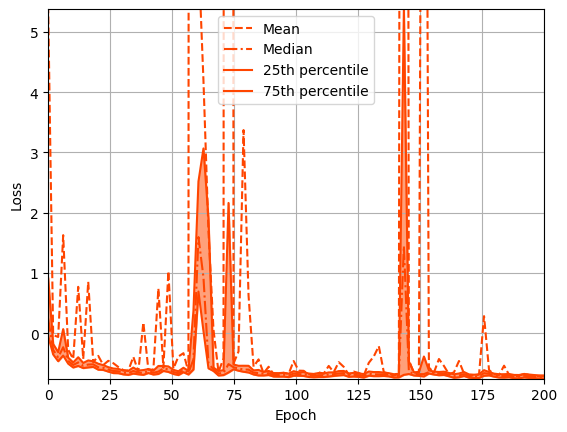

In [22]:
# Release memory and plot
manager.release_dataset()
manager.plot_train_stats()
manager.plot_valid_stats()

## 7. Testing & Visualization

Based on the paper's source code workflow from `single_reconstruction.py`.

In [ ]:
# Find the best checkpoint by testing all epochs
import shutil
import os
import numpy as np

DRIVE_CHECKPOINTS = '/content/drive/MyDrive/ECG_Reconstruction/Checkpoints'
LOCAL_OUTPUT = manager.output_folder

# Get all available checkpoints
checkpoints = sorted([d for d in os.listdir(DRIVE_CHECKPOINTS) if d.startswith('epoch_')])
print(f"Found {len(checkpoints)} checkpoints: {checkpoints}")

# Load test dataset once
print("\nLoading test dataset...")
manager.load_dataset(test=True)

results = []

for checkpoint_name in checkpoints:
    checkpoint_path = f"{DRIVE_CHECKPOINTS}/{checkpoint_name}"
    
    # Copy checkpoint to local
    src_state_dict = f"{checkpoint_path}/state_dict"
    dst_state_dict = f"{LOCAL_OUTPUT}/state_dict"
    
    if os.path.exists(src_state_dict):
        if os.path.exists(dst_state_dict):
            shutil.rmtree(dst_state_dict)
        shutil.copytree(src_state_dict, dst_state_dict)
        
        # Load model
        manager.load_model()
        
        # Reset test arrays
        manager.test_mserrors = []
        manager.test_rsquareds = []
        manager.test_element_ids = []
        manager.test_mserrors_per_sub_class = [[] for _ in manager.sub_classes]
        manager.test_rsquareds_per_sub_class = [[] for _ in manager.sub_classes]
        
        # Run test
        manager.data_loader.shuffle('test')
        manager.test()
        
        # Get results
        mean_r2 = np.mean(manager.test_rsquareds) * 100
        median_r2 = np.median(manager.test_rsquareds) * 100
        mean_mse = np.mean(manager.test_mserrors)
        
        results.append({
            'checkpoint': checkpoint_name,
            'mean_r2': mean_r2,
            'median_r2': median_r2,
            'mean_mse': mean_mse
        })
        
        print(f"{checkpoint_name}: Mean R² = {mean_r2:.2f}%, Median R² = {median_r2:.2f}%, MSE = {mean_mse:.6f}")

# Release dataset
manager.release_dataset()

# Find best checkpoint
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

# Sort by mean R² (descending)
results_sorted = sorted(results, key=lambda x: x['mean_r2'], reverse=True)

print(f"\n{'Checkpoint':<15} {'Mean R²':>10} {'Median R²':>12} {'MSE':>12}")
print("-" * 50)
for r in results_sorted:
    print(f"{r['checkpoint']:<15} {r['mean_r2']:>9.2f}% {r['median_r2']:>11.2f}% {r['mean_mse']:>12.6f}")

best = results_sorted[0]
print("\n" + "=" * 70)
print(f"BEST CHECKPOINT: {best['checkpoint']}")
print(f"  Mean R²:   {best['mean_r2']:.2f}%")
print(f"  Median R²: {best['median_r2']:.2f}%")
print(f"  MSE:       {best['mean_mse']:.6f}")
print("=" * 70)

In [ ]:
# Load the BEST checkpoint and generate visualization plots
# Run this AFTER cell-31 finds the best checkpoint

import shutil
import os

# Use the best checkpoint from cell-31 results
# Change this to the best checkpoint name from the results above
BEST_CHECKPOINT = best['checkpoint']  # e.g., 'epoch_190'

print(f"Using best checkpoint: {BEST_CHECKPOINT}")
print("=" * 60)

# Copy best checkpoint to local
DRIVE_CHECKPOINTS = '/content/drive/MyDrive/ECG_Reconstruction/Checkpoints'
checkpoint_path = f"{DRIVE_CHECKPOINTS}/{BEST_CHECKPOINT}"
LOCAL_OUTPUT = manager.output_folder

src_state_dict = f"{checkpoint_path}/state_dict"
dst_state_dict = f"{LOCAL_OUTPUT}/state_dict"

if os.path.exists(dst_state_dict):
    shutil.rmtree(dst_state_dict)
shutil.copytree(src_state_dict, dst_state_dict)

# Load model
print("\n[1/4] Loading best model...")
manager.load_model()

# Load test dataset
print("[2/4] Loading test dataset...")
manager.load_dataset(test=True)

# Plot random reconstruction examples
print("[3/4] Plotting random ECG reconstruction examples...")
manager.plot_random_example(plot_format='png')

# Plot error examples at different percentiles
print("[4/4] Plotting error examples at percentiles...")
manager.data_loader.shuffle('test')
manager.plot_error_example(plot_format='png')

# Release dataset
manager.release_dataset()

print("\n" + "=" * 60)
print(f"VISUALIZATION COMPLETE using {BEST_CHECKPOINT}")
print(f"Best Mean R²: {best['mean_r2']:.2f}%")
print("=" * 60)

In [ ]:
# Step 3: Display test results summary
import numpy as np

test_stats_path = f"{manager.output_folder}/test_stats/"

if os.path.exists(f"{test_stats_path}/test_rsquareds.npy"):
    r2_scores = np.load(f"{test_stats_path}/test_rsquareds.npy")
    mse_scores = np.load(f"{test_stats_path}/test_mserrors.npy")
    
    print("=" * 60)
    print("TEST RESULTS SUMMARY")
    print("=" * 60)
    print(f"Number of test samples: {len(r2_scores)}")
    print(f"\nR2 Score (coefficient of determination):")
    print(f"  Mean:   {np.mean(r2_scores)*100:.2f}%")
    print(f"  Median: {np.median(r2_scores)*100:.2f}%")
    print(f"  Std:    {np.std(r2_scores)*100:.2f}%")
    print(f"  Min:    {np.min(r2_scores)*100:.2f}%")
    print(f"  Max:    {np.max(r2_scores)*100:.2f}%")
    print(f"\nMSE (Mean Squared Error):")
    print(f"  Mean:   {np.mean(mse_scores):.6f}")
    print(f"  Median: {np.median(mse_scores):.6f}")
    print("=" * 60)
    print(f"Target R2: 72.98% (paper with 627K ECGs)")
    print(f"Your R2:   {np.mean(r2_scores)*100:.2f}% (with ~22K ECGs)")
    print("=" * 60)
else:
    print("Test stats not found. Run the test cell first.")

In [ ]:
# Step 4: Display generated images
from IPython.display import Image, display
import glob
import os

output_folder = manager.output_folder
print(f"Output folder: {output_folder}")

# List all contents of output folder
print("\nOutput folder contents:")
if os.path.exists(output_folder):
    for item in os.listdir(output_folder):
        item_path = os.path.join(output_folder, item)
        if os.path.isdir(item_path):
            files = os.listdir(item_path)
            print(f"  {item}/ ({len(files)} items)")
else:
    print("  Output folder does not exist!")

# Display random ECG reconstruction examples
print("\n" + "=" * 60)
print("RANDOM ECG RECONSTRUCTION EXAMPLES")
print("=" * 60)
random_medical = f"{output_folder}/random_plot/medical/"
random_standard = f"{output_folder}/random_plot/standard/"

if os.path.exists(random_medical):
    random_plots = [f for f in os.listdir(random_medical) if f.endswith('.png')]
    print(f"Found {len(random_plots)} medical plots")
    for img_name in random_plots[:3]:
        img_path = os.path.join(random_medical, img_name)
        print(f"\n{img_name}")
        display(Image(filename=img_path, width=1000))
elif os.path.exists(random_standard):
    random_plots = [f for f in os.listdir(random_standard) if f.endswith('.png')]
    print(f"Found {len(random_plots)} standard plots")
    for img_name in random_plots[:3]:
        img_path = os.path.join(random_standard, img_name)
        print(f"\n{img_name}")
        display(Image(filename=img_path, width=1000))
else:
    print("No random plots found. Check if plot_random_example() ran successfully.")

# Display error examples at different percentiles
print("\n" + "=" * 60)
print("ERROR EXAMPLES AT DIFFERENT PERCENTILES")
print("=" * 60)
error_medical = f"{output_folder}/error_plot/medical/"

if os.path.exists(error_medical):
    for percent_folder in sorted(os.listdir(error_medical)):
        percent_path = os.path.join(error_medical, percent_folder)
        if os.path.isdir(percent_path):
            for img_name in os.listdir(percent_path):
                if img_name.endswith('.png'):
                    img_path = os.path.join(percent_path, img_name)
                    print(f"\n{percent_folder}/{img_name}")
                    display(Image(filename=img_path, width=1000))
else:
    print("No error plots found. Check if plot_error_example() ran successfully.")

# Display test statistics plots
print("\n" + "=" * 60)
print("TEST STATISTICS PLOTS")
print("=" * 60)
test_stats = f"{output_folder}/test_stats/"

if os.path.exists(test_stats):
    test_plots = [f for f in os.listdir(test_stats) if f.endswith('.png')]
    print(f"Found {len(test_plots)} test stat plots")
    for img_name in test_plots[:6]:
        img_path = os.path.join(test_stats, img_name)
        print(f"\n{img_name}")
        display(Image(filename=img_path, width=600))
else:
    print("No test statistic plots found.")

In [ ]:
# Step 5: Plot training curves
print("=" * 60)
print("TRAINING CURVES")
print("=" * 60)

# Load and plot training stats
manager.load_train_stats()
manager.plot_train_stats()

# Load and plot validation stats  
manager.load_valid_stats()
manager.plot_valid_stats()

# Display the plots
train_plot = f"{manager.output_folder}/train_stats/train_losses.png"
valid_plot = f"{manager.output_folder}/valid_stats/valid_losses.png"

if os.path.exists(train_plot):
    print("\nTraining Loss Curve:")
    display(Image(filename=train_plot))

if os.path.exists(valid_plot):
    print("\nValidation Loss Curve:")
    display(Image(filename=valid_plot))

## 8. Save Results to Google Drive

In [ ]:
# Save all results to Google Drive
import shutil
import os

drive_results_path = '/content/drive/MyDrive/ECG_Reconstruction_Results'
os.makedirs(drive_results_path, exist_ok=True)

# Copy entire output folder to Drive
output_folder = manager.output_folder
if os.path.exists(output_folder):
    # Create a clean destination path
    dest_path = f"{drive_results_path}/Reconstruction_Results"
    if os.path.exists(dest_path):
        shutil.rmtree(dest_path)
    shutil.copytree(output_folder, dest_path)
    print(f"Results saved to: {dest_path}")
    
    # List what was saved
    print("\nSaved folders:")
    for item in os.listdir(dest_path):
        item_path = os.path.join(dest_path, item)
        if os.path.isdir(item_path):
            num_files = len([f for f in os.listdir(item_path) if os.path.isfile(os.path.join(item_path, f))])
            print(f"  {item}/ ({num_files} files)")

print("\nDone! All results saved to Google Drive.")